In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score



df = pd.read_csv('heart_disease_uci.csv')
print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [220]:
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'id']).reset_index(drop=True)

df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col] = df.groupby('dataset')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])

df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['sex'] = (df['sex'] == 'Male').astype('Int64')
df['fbs'] = df['fbs'].astype('Int64')
df['exang'] = df['exang'].astype('Int64')
df['dataset'] = df['dataset'].astype('category').cat.codes
df['cp'] = df['cp'].astype('category').cat.codes
df['restecg'] = df['restecg'].astype('category').cat.codes
df['num'] = (df['num'] > 0).astype(int)

df = df.drop(columns=['id'])
df = df.drop(columns=['ca'])
df = df.drop(columns=['thal'])
df = df.drop(columns=['slope'])
display(df.head())
print(df.info())
print(df['dataset'].unique())

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0
1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1
2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1
3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0
4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,0


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    Int64  
 2   dataset   918 non-null    int8   
 3   cp        918 non-null    int8   
 4   trestbps  918 non-null    float64
 5   chol      918 non-null    float64
 6   fbs       918 non-null    Int64  
 7   restecg   918 non-null    int8   
 8   thalch    918 non-null    float64
 9   exang     918 non-null    Int64  
 10  oldpeak   918 non-null    float64
 11  num       918 non-null    int64  
dtypes: Int64(3), float64(4), int64(2), int8(3)
memory usage: 70.1 KB
None
[0 1 2 3]


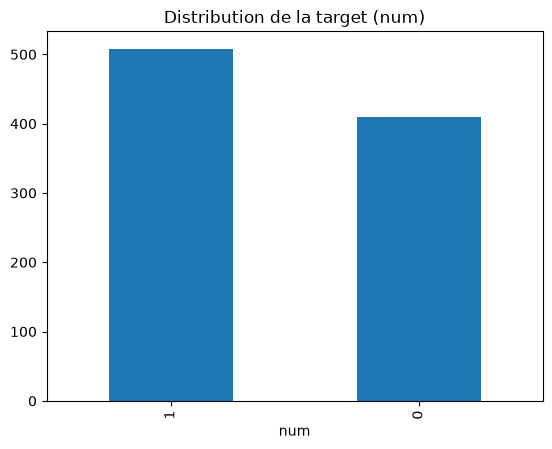

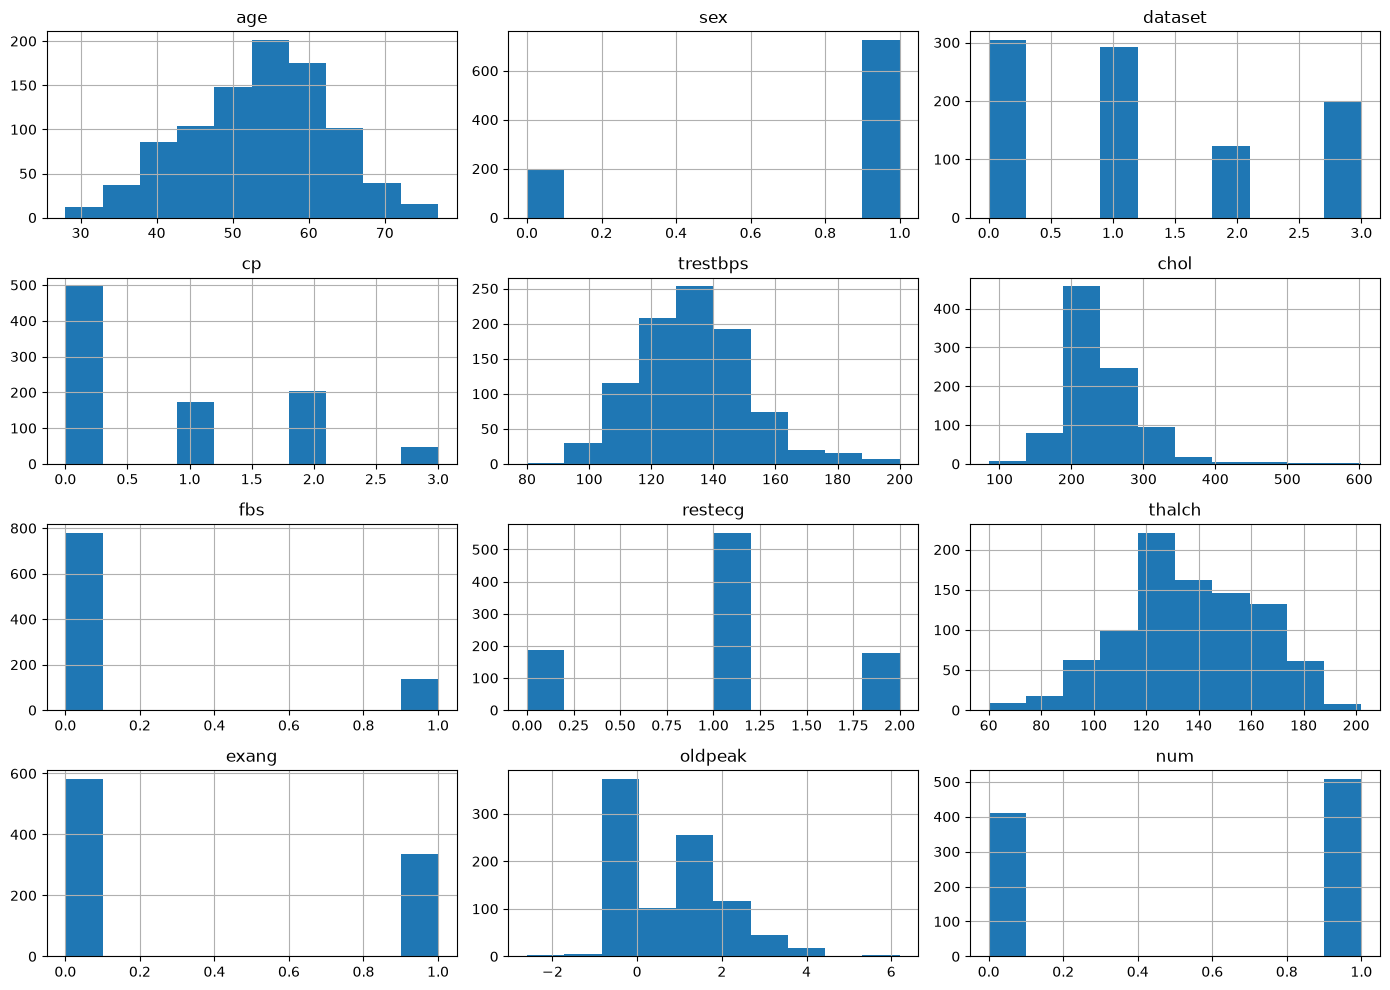

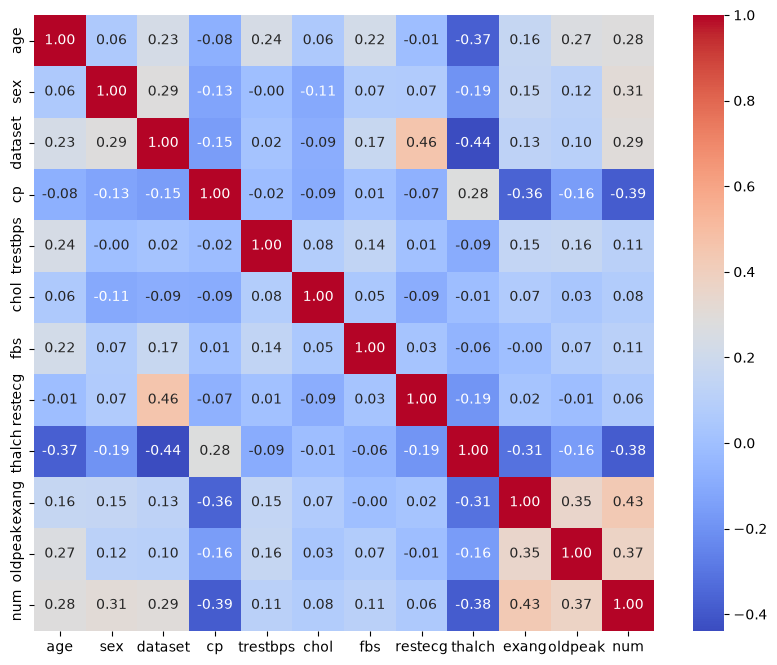

In [221]:

df['num'].value_counts().plot(kind='bar')
plt.title('Distribution de la target (num)')
plt.show()

df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [222]:
X = df.drop(columns=['num'])
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7989


Accuracy: 0.7989
Precision: 0.8426
Recall: 0.8198
F1 Score: 0.8311


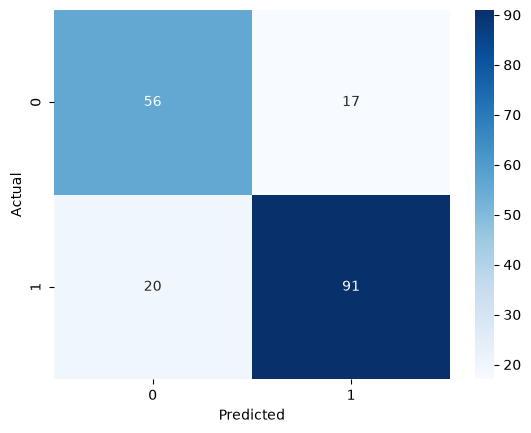

In [223]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")